# Segmentación con reposo (exp_08)

Variante del pipeline de decodificación neural con SNNs que **entrena incluyendo los tramos de reposo** entre trials y **evalúa en continuo**, como el paper (Sec. III-D: "tested on continuous recordings without segmentation").

**Fase 1:Preparacion de datos**
1. Cargar MUA_matrix (spike detection ya hecho)
2. Extraer eventos de trials del .nev
3. Extraer y procesar targets del .ns2
4. Segmentar en ventanas (incluyendo el reposo)
5. Crear dataset y dataloaders

**Fase 2: SNN+entrenamiento**
1. Arquitectura SNN
2. Conf entrenamiento
3. Loop entrenamiento

**Fase 3: Evluacion y resultados**
1. Curvas de entrenamiento
2. Evaluación test CONTINUO (cc, R2)
3. Visualizacion Prediccion vs Target

# FASE 1: PREPARACION DE DATOS


In [1]:
# ============================================================================
# PASO 1: CARGA DE MUA_matrix
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import neo
from collections import Counter
import os

# ===== CONFIGURACIÓN DEL EXPERIMENTO =====
# exp_08 = entrenar INCLUYENDO los tramos de reposo entre trials y evaluar en
#   CONTINUO, como el paper. Diferencias con exp_07:
#     - se trocea TODA la linea temporal en ventanas consecutivas (trials + reposo)
#     - NO se resta offset (zero-crossing): targets en valor absoluto, z-score
#     - split SECUENCIAL por TIEMPO (no por trials)
EXPERIMENTO_ID   = "exp_08"
EXPERIMENTO_DESC = "reposo_continuo"
NORMALIZACION    = "zscore"
ZERO_CROSSING    = False

nev_path = os.path.join('..', '..', 'datos', 'i140703-001-03.nev')
ns2_path = os.path.join('..', '..', 'datos', 'i140703-001.ns2')

MUA_matrix = np.load('MUA_matrix_96channels.npy')
print(f"  MUA_matrix: {MUA_matrix.shape}")
print(f"  Canales: {MUA_matrix.shape[0]}")
print(f"  Bins: {MUA_matrix.shape[1]:,}")
print(f"  Duración: {MUA_matrix.shape[1] / 1000:.1f} s")

  MUA_matrix: (96, 1003210)
  Canales: 96
  Bins: 1,003,210
  Duración: 1003.2 s


In [2]:
# ============================================================================
# PASO 2: EXTRAER EVENTOS DEL ARCHIVO .NEV
# ============================================================================

# Leer archivo .nev
reader_nev = neo.io.BlackrockIO(nev_path)
blk_nev = reader_nev.read_block(load_waveforms=False)
seg_nev = blk_nev.segments[0]


print(f"Eventos encontrados: {len(seg_nev.events)}")
for i, event in enumerate(seg_nev.events):
    print(f"  [{i}] {len(event.times)} eventos")
    
""""

└── Block
    └── Segment[0]
        └── events[]
            ├── Event[0]: Digital events (códigos de trial)
            │   ├── times: [0.5, 1.2, 1.8, ...] → cuándo ocurrió cada evento (segundos)
            │   └── labels: [65313, 65345, ...] → qué tipo de evento (código numérico)
            │
            └── Event[1]: (otros eventos si existen)

"""


Eventos encontrados: 3
  [0] 1317 eventos
  [1] 0 eventos
  [2] 0 eventos


'"\n\n└── Block\n    └── Segment[0]\n        └── events[]\n            ├── Event[0]: Digital events (códigos de trial)\n            │   ├── times: [0.5, 1.2, 1.8, ...] → cuándo ocurrió cada evento (segundos)\n            │   └── labels: [65313, 65345, ...] → qué tipo de evento (código numérico)\n            │\n            └── Event[1]: (otros eventos si existen)\n\n'

In [3]:
# ============================================================================
# PASO 3: ANALIZAR CÓDIGOS DE EVENTOS
# ============================================================================

# Extraer eventos digitales
digital_events = seg_nev.events[0]  
event_times = digital_events.times.magnitude     # Cuándo ( tiempo en segundos)
event_codes = digital_events.labels.astype(int)  # Qué código

print(f"Total de eventos: {len(event_times)}")
print(f"Duración de la grabación: {event_times[-1]:.2f} segundos")

# Contar frecuencia de cada código
code_counts = Counter(event_codes)
print(f"\nCódigos únicos encontrados: {len(code_counts)}")
print("\nFrecuencia de cada código:")
for code, count in sorted(code_counts.items()):
    print(f"  {code}: {count} veces")

Total de eventos: 1317
Duración de la grabación: 1002.93 segundos

Códigos únicos encontrados: 18

Frecuencia de cada código:
  65296: 163 veces
  65312: 161 veces
  65360: 319 veces
  65365: 84 veces
  65366: 78 veces
  65369: 80 veces
  65370: 76 veces
  65376: 1 veces
  65381: 22 veces
  65382: 76 veces
  65385: 76 veces
  65386: 22 veces
  65390: 1 veces
  65440: 11 veces
  65509: 71 veces
  65510: 2 veces
  65513: 3 veces
  65514: 71 veces


In [4]:
# ============================================================================
# PASO 4: PARSEAR LOS TRIALS del .ns2
# ============================================================================

# Códigos para Monkey N (según Table 2 del PDF del dataset)
CODES_N = {
    'TS_ON': 65296,      # Trial Start
    'WS_ON': 65360,      # Warning Signal ON (también CUE-OFF)
    'PG_ON': 65365,      # Precision Grip CUE
    'SG_ON': 65370,      # Side Grip CUE
    'LF_ON': 65369,      # Low Force GO
    'HF_ON': 65366,      # High Force GO
    'SR_LF': 65385,      # Switch Release (LF)
    'SR_HF': 65382,      # Switch Release (HF)
    'RW_PG': 65509,      # Reward (PG)
    'RW_SG': 65514,      # Reward (SG)
    'WS_OFF': 65376,     # Trial end
    'STOP': 65312,       # Trial end alternativo
}

# Códigos a ignorar (errores de muestreo según el PDF)
IGNORE_CODES = {65381, 65386, 65390, 65440, 65504}

# Encontrar índices de TS-ON (inicio de cada trial)
ts_on_indices = np.where(event_codes == CODES_N['TS_ON'])[0]
print(f"Trials encontrados (TS-ON): {len(ts_on_indices)}")

# Parsear cada trial
trials = []
for i, start_idx in enumerate(ts_on_indices):
    # Determinar el final del trial (siguiente TS-ON o fin de grabación)
    if i < len(ts_on_indices) - 1:
        end_idx = ts_on_indices[i + 1]
    else:
        end_idx = len(event_codes)
    
    # Extraer eventos de este trial
    trial_codes = event_codes[start_idx:end_idx]
    trial_times = event_times[start_idx:end_idx]
    
    # Filtrar códigos a ignorar
    mask = ~np.isin(trial_codes, list(IGNORE_CODES))
    trial_codes = trial_codes[mask]
    trial_times = trial_times[mask]
    
    # Extraer info del trial y si fue correcto
    trial_info = {
        'trial_id': i + 1,
        'ts_on': trial_times[0],
        'grip_type': 'PG' if CODES_N['PG_ON'] in trial_codes else 
                     'SG' if CODES_N['SG_ON'] in trial_codes else None,
        'force_type': 'LF' if CODES_N['LF_ON'] in trial_codes else
                      'HF' if CODES_N['HF_ON'] in trial_codes else None,
        'correct': CODES_N['RW_PG'] in trial_codes or CODES_N['RW_SG'] in trial_codes,
        'rw_on': None  # Se llena después
    }
    
    # Buscar tipo de grip
    if CODES_N['PG_ON'] in trial_codes:
        trial_info['grip_type'] = 'PG'
    elif CODES_N['SG_ON'] in trial_codes:
        trial_info['grip_type'] = 'SG'
    
    # Buscar tipo de fuerza
    if CODES_N['LF_ON'] in trial_codes:
        trial_info['force_type'] = 'LF'
    elif CODES_N['HF_ON'] in trial_codes:
        trial_info['force_type'] = 'HF'
    
    # Buscar tiempo de recompensa (indica trial correcto)
    for code in [CODES_N['RW_PG'], CODES_N['RW_SG']]:
        if code in trial_codes:
            trial_info['correct'] = True
            idx = np.where(trial_codes == code)[0][0]
            trial_info['rw_on'] = trial_times[idx]
            break
    
    # Buscar fin del trial (WS-OFF o STOP)
    for code in [CODES_N['WS_OFF'], CODES_N['STOP']]:
        if code in trial_codes:
            idx = np.where(trial_codes == code)[0][-1]
            trial_info['ws_off'] = trial_times[idx]
            break
    
    trials.append(trial_info)

# Convertir a DataFrame
df_trials = pd.DataFrame(trials)

print(f"\n{'='*60}")
print("RESUMEN DE TRIALS")
print(f"{'='*60}")
print(f"Total trials: {len(df_trials)}")
print(f"Trials correctos: {df_trials['correct'].sum()}")
print(f"Trials con error: {(~df_trials['correct']).sum()}")

print(f"\nPor tipo de trial:")
print(df_trials.groupby(['grip_type', 'force_type', 'correct']).size())

print(f"\nPrimeros 10 trials:")
print(df_trials.head(10))

Trials encontrados (TS-ON): 163

RESUMEN DE TRIALS
Total trials: 163
Trials correctos: 142
Trials con error: 21

Por tipo de trial:
grip_type  force_type  correct
PG         HF          False       4
                       True       36
           LF          False       7
                       True       35
SG         HF          False       2
                       True       36
           LF          False       3
                       True       35
dtype: int64

Primeros 10 trials:
   trial_id      ts_on grip_type force_type  correct      rw_on     ws_off
0         1   1.314133        SG         HF     True   4.535700   4.830600
1         2   7.131433        SG         HF     True  10.121567  10.502400
2         3  12.803200        PG         HF    False        NaN  16.912500
3         4  19.212300        SG         LF     True  22.432900  22.725833
4         5  25.026700        SG         LF     True  28.116400  28.471833
5         6  30.772633        PG         HF     True  34.

In [5]:
# ============================================================================
# CELDA 5: EXTRAER TARGETS DEL .ns2
# ============================================================================

# Leer archivo .ns2 con todas las señales separadas
reader = neo.io.BlackrockIO(ns2_path)
blk = reader.read_block(signal_group_mode='split-all')
seg = blk.segments[0]

print(f"Total de señales analógicas: {len(seg.analogsignals)}")
print("\nSeñales de SENSORES (índices 96-101):")
for i in range(96, 102):
    sig = seg.analogsignals[i]
    name = sig.array_annotations['channel_names'][0]
    ch_id = sig.array_annotations['channel_ids'][0]
    print(f"  [{i}] {name:8} (canal {ch_id})")

# Extraer señales (índices 96-101)---Los indices 0-95 son de los 96 canales de MUA(los canales neuronales), 96+ son de los sensores
GFpr1   = np.array(seg.analogsignals[96]).flatten()   # Fuerza dedo índice (PG:precision grip)
GFside1 = np.array(seg.analogsignals[97]).flatten()   # Fuerza dedo medio (SG:side grip)
GFpr2   = np.array(seg.analogsignals[98]).flatten()   # Fuerza pulgar (PG:precision grip)
GFside2 = np.array(seg.analogsignals[99]).flatten()   # Fuerza pulgar (SG:side grip)
Displ   = np.array(seg.analogsignals[101]).flatten()  # desplazamiento del objeto 
#NOTA: El indice 100 es la fuerza total, no se usa en este caso
#NOTA: Trials PG(precision grip): GFpr1 (índice) y GFpr2 (pulgar)--pinza
#NOTA: Trials SG(side grip): GFside1 (medio) y GFside2 (pulgar)--agarre lateral

#Relacion con los 5 outputs de la SNN:
# 1: GFpr1--(MAF)--Fuerza
# 2: GFside1--(MAF)--Fuerza
# 3: GFpr2--(MAF)--Fuerza
# 4: GFside2--(MAF)--Fuerza
# 5: Displ--(diferenciar)--Velocidad
print(f"\nSeñales extraídas:")
print(f"  GFpr1:   {GFpr1.shape}, rango: [{GFpr1.min():.1f}, {GFpr1.max():.1f}]")
print(f"  GFside1: {GFside1.shape}, rango: [{GFside1.min():.1f}, {GFside1.max():.1f}]")
print(f"  GFpr2:   {GFpr2.shape}, rango: [{GFpr2.min():.1f}, {GFpr2.max():.1f}]")
print(f"  GFside2: {GFside2.shape}, rango: [{GFside2.min():.1f}, {GFside2.max():.1f}]")
print(f"  Displ:   {Displ.shape}, rango: [{Displ.min():.1f}, {Displ.max():.1f}]")


Total de señales analógicas: 198

Señales de SENSORES (índices 96-101):
  [96] GFpr1    (canal 137)
  [97] GFside1  (canal 138)
  [98] GFpr2    (canal 139)
  [99] GFside2  (canal 140)
  [100] LF       (canal 141)
  [101] Displ    (canal 143)

Señales extraídas:
  GFpr1:   (1003210,), rango: [49.3, 419.8]
  GFside1: (1003210,), rango: [8.4, 291.5]
  GFpr2:   (1003210,), rango: [5.8, 615.1]
  GFside2: (1003210,), rango: [5.3, 617.7]
  Displ:   (1003210,), rango: [1578.3, 2478.3]


In [6]:
# ============================================================================
# CELDA 6: PROCESAR TARGETS CON MAF (según paper)
# ============================================================================
#Esta celda aplica el preprocesamiento de targets, medidante un suavizado (MAF) de las señales de fuerza y velocidad (derivada de la posición)

def moving_average_filter(signal, order):
    """Filtro de media móvil de orden N."""
    kernel = np.ones(order) / order
    return np.convolve(signal, kernel, mode='same')

# Velocidad: MAF(64) → derivada → MAF(16)
position_smooth = moving_average_filter(Displ, order=64)
velocity = np.diff(position_smooth)
velocity = np.append(velocity, velocity[-1])  # Mantener longitud
velocity_smooth = moving_average_filter(velocity, order=16)

# Fuerzas: MAF(64)
GFpr1_smooth   = moving_average_filter(GFpr1, order=64)
GFside1_smooth = moving_average_filter(GFside1, order=64)
GFpr2_smooth   = moving_average_filter(GFpr2, order=64)
GFside2_smooth = moving_average_filter(GFside2, order=64)

# Crear matriz de targets: (5, T) = [velocidad, F1, F2, F3, F4]
targets_matrix = np.vstack([
    velocity_smooth,   # [0] Velocity
    GFpr1_smooth,      # [1] Fuerza índice PG
    GFside1_smooth,    # [2] Fuerza medio SG
    GFpr2_smooth,      # [3] Fuerza pulgar PG
    GFside2_smooth     # [4] Fuerza pulgar SG
]).astype(np.float32)

print(f"  Targets matrix: {targets_matrix.shape}")


  Targets matrix: (5, 1003210)


In [7]:
# ============================================================================
# CELDA 7: SEGMENTAR EN VENTANAS (exp_08: incluye el reposo entre trials)
# ============================================================================
# A diferencia de exp_07 (un segmento por trial), aqui se trocea TODA la linea
# temporal en ventanas consecutivas de longitud fija, cubriendo tambien los
# tramos de reposo entre trials, para que la red aprenda a estar plana en reposo.

print("="*60)
print("SEGMENTACIÓN EN VENTANAS (con reposo)")
print("="*60)

# Trials correctos (para metadata y para localizar el tramo de test)
df_correct = df_trials[df_trials['correct'] == True].copy().reset_index(drop=True)
df_correct['duration_ms'] = ((df_correct['rw_on'] - df_correct['ts_on']) * 1000).astype(int)
TRIAL_LENGTH = int(df_correct['duration_ms'].min())
L = TRIAL_LENGTH
df_trial_info = df_correct[['trial_id', 'grip_type', 'force_type']].copy()

# Span continuo: del inicio del primer trial al reward del ultimo
t0 = int(df_correct.iloc[0]['ts_on'] * 1000)
t1 = int(df_correct.iloc[-1]['rw_on'] * 1000)
t1 = min(t1, MUA_matrix.shape[1], targets_matrix.shape[1])
span = t1 - t0
tr_end = t0 + int(0.8 * span)   # split SECUENCIAL por tiempo
va_end = t0 + int(0.9 * span)
print(f"  span continuo: {span/1000:.0f} s   (longitud de ventana L = {L} ms)")
print(f"  train [{t0},{tr_end})   val [{tr_end},{va_end})   test [{va_end},{t1})")

def make_windows(a, b):
    Xs, Ys = [], []
    s = a
    while s + L <= b:
        Xs.append(MUA_matrix[:, s:s+L].T)        # (L, 96)
        Ys.append(targets_matrix[:, s:s+L].T)    # (L, 5)
        s += L
    return np.array(Xs, dtype=np.float32), np.array(Ys, dtype=np.float32)

X_train_w, Y_train_w = make_windows(t0, tr_end)
X_val_w,   Y_val_w   = make_windows(tr_end, va_end)
print(f"  ventanas train: {len(X_train_w)}   val: {len(X_val_w)}")

SEGMENTACIÓN EN VENTANAS (con reposo)
  span continuo: 998 s   (longitud de ventana L = 2990 ms)
  train [1314,800070)   val [800070,899915)   test [899915,999760)
  ventanas train: 267   val: 33


In [8]:
dur = ((df_correct['rw_on'] - df_correct['ts_on']) * 1000).astype(int)
print(f"Duración mínima (la que se usa): {dur.min()} ms")
print(f"Duración media:  {dur.mean():.0f} ms")
print(f"Duración máxima: {dur.max()} ms")
print(f"Información descartada en el trial más largo: {dur.max() - dur.min()} ms ({100*(dur.max()-dur.min())/dur.max():.0f}%)")
print(f"Pérdida media por trial: {dur.mean() - dur.min():.0f} ms")

Duración mínima (la que se usa): 2990 ms
Duración media:  3397 ms
Duración máxima: 3701 ms
Información descartada en el trial más largo: 711 ms (19%)
Pérdida media por trial: 407 ms


In [9]:
# ============================================================================
# CELDA 8: NORMALIZAR TARGETS (z-score con stats de las ventanas de train)
# ============================================================================
# exp_08 NO aplica zero-crossing: los targets se dejan en valor absoluto y se
# z-scorean con las estadisticas de las ventanas de train (sin data leakage).
var_names = ['Velocity', 'GFpr1', 'GFside1', 'GFpr2', 'GFside2']

Y_mean = Y_train_w.reshape(-1, 5).mean(axis=0)
Y_std  = Y_train_w.reshape(-1, 5).std(axis=0); Y_std[Y_std == 0] = 1
Y_train_norm = (Y_train_w - Y_mean) / Y_std
Y_val_norm   = (Y_val_w   - Y_mean) / Y_std
norm_params = {'tipo': 'zscore', 'mean': Y_mean, 'std': Y_std, 'baseline': np.zeros(5)}

print("Normalización: Z-score (mean/std de las ventanas de train)")
for i, name in enumerate(var_names):
    print(f"{name}: mean={Y_train_norm[:,:,i].mean():.4f}, std={Y_train_norm[:,:,i].std():.4f}")

Normalización: Z-score (mean/std de las ventanas de train)
Velocity: mean=0.0000, std=1.0008
GFpr1: mean=-0.0029, std=0.9995
GFside1: mean=-0.0011, std=0.9999
GFpr2: mean=-0.0001, std=0.9998
GFside2: mean=-0.0007, std=1.0011


In [10]:
# ============================================================================
# CELDA 10: DATASET Y DATALOADERS (a partir de las ventanas con reposo)
# ============================================================================
class TrialDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.FloatTensor(X)
        self.Y = torch.FloatTensor(Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_set = TrialDataset(X_train_w, Y_train_norm)
val_set   = TrialDataset(X_val_w,   Y_val_norm)

batch_size = 10
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)

print(f"  Ventanas train: {len(train_set)}   val: {len(val_set)}")
print(f"  Batch size: {batch_size}   Longitud de ventana: {L} ms")
bx, by = next(iter(train_loader))
print(f"  Batch ejemplo: X={bx.shape}, Y={by.shape}")

  Ventanas train: 267   val: 33
  Batch size: 10   Longitud de ventana: 2990 ms
  Batch ejemplo: X=torch.Size([10, 2990, 96]), Y=torch.Size([10, 2990, 5])


# FASE 2: ARQUITECTURA SNN + LOOP ENTRENAMIENTO


In [11]:
# ============================================================================
# PASO 1: ARQUITECTURA SNN  (réplica fiel al paper / código de Martis)
# ============================================================================
# Topología: 96 → 64 → 128 → 64 → 5
# CORREGIDO respecto a versiones anteriores:
#   - bias=False en TODAS las capas Linear (Martis/paper, FPGA-friendly)
#   - β como TENSOR por neurona (no escalar por capa)

import snntorch as snn
from snntorch import surrogate
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# Hiperparámetros
num_inputs = 96       # 96 electrodos Utah Array
num_hidden0 = 64      # Primera capa oculta
num_hidden1 = 128     # Segunda capa oculta
num_hidden2 = 64      # Tercera capa oculta
num_outputs = 5       # Dataset I: velocidad + 4 fuerzas

beta_init_value = 0.9       # Valor inicial de β (será entrenable, uno por neurona)
threshold_value = 0.1       # Umbral para generar spike
spike_grad = surrogate.fast_sigmoid()  # Gradiente surrogate para backprop

# β POR NEURONA (tensor, no escalar). Cada neurona aprende su propia constante de tiempo.
# Esto es lo que hace Martis por defecto ('1beta4layer': False).
beta_layer0 = torch.ones(num_hidden0) * beta_init_value
beta_layer1 = torch.ones(num_hidden1) * beta_init_value
beta_layer2 = torch.ones(num_hidden2) * beta_init_value
beta_layer3 = torch.ones(num_outputs) * beta_init_value

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # CAPA 0: 96 → 64  (bias=False, β por neurona)
        self.fc0 = nn.Linear(num_inputs, num_hidden0, bias=False)
        self.lif0 = snn.Leaky(beta=beta_layer0, learn_beta=True,
                              threshold=threshold_value, spike_grad=spike_grad,
                              reset_mechanism='subtract')

        # CAPA 1: 64 → 128
        self.fc1 = nn.Linear(num_hidden0, num_hidden1, bias=False)
        self.lif1 = snn.Leaky(beta=beta_layer1, learn_beta=True,
                              threshold=threshold_value, spike_grad=spike_grad,
                              reset_mechanism='subtract')

        # CAPA 2: 128 → 64
        self.fc2 = nn.Linear(num_hidden1, num_hidden2, bias=False)
        self.lif2 = snn.Leaky(beta=beta_layer2, learn_beta=True,
                              threshold=threshold_value, spike_grad=spike_grad,
                              reset_mechanism='subtract')

        # CAPA 3: 64 → 5 (salida SIN reset)
        self.fc3 = nn.Linear(num_hidden2, num_outputs, bias=False)
        self.lif3 = snn.Leaky(beta=beta_layer3, learn_beta=True,
                              threshold=threshold_value, spike_grad=spike_grad,
                              reset_mechanism='none')

    def forward(self, x):
        # x shape: [batch, tiempo, canales]
        batch_size = x.shape[0]
        num_steps = x.shape[1]

        # Inicializar potenciales de membrana
        mem0 = self.lif0.init_leaky()
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        # Lista para guardar salida de cada timestep
        mem3_rec = []

        # Recorrer secuencia temporal
        for step in range(num_steps):
            x_t = x[:, step, :]  # [batch, 96]

            # Capa 0
            cur0 = self.fc0(x_t)
            spk0, mem0 = self.lif0(cur0, mem0)

            # Capa 1
            cur1 = self.fc1(spk0)
            spk1, mem1 = self.lif1(cur1, mem1)

            # Capa 2
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            # Capa 3 (salida) - guardamos potencial porque la salida es PREDICCION
            cur3 = self.fc3(spk2)
            _, mem3 = self.lif3(cur3, mem3)

            mem3_rec.append(mem3)

        # Stack: [batch, tiempo, 5]
        return torch.stack(mem3_rec, dim=1) # [batch, time, 5]

# Crear modelo
modelo = Net().to(device)

# Resumen de parámetros (verificación)
n_params = sum(p.numel() for p in modelo.parameters())
n_params_beta = sum(p.numel() for n, p in modelo.named_parameters() if 'beta' in n.lower() or 'recurrent' in n.lower())
print(f"  Parámetros totales del modelo: {n_params:,}")
print(f"  bias = False en todas las Linear (FPGA-friendly)")
print(f"  β por neurona: {num_hidden0}+{num_hidden1}+{num_hidden2}+{num_outputs} = {num_hidden0+num_hidden1+num_hidden2+num_outputs} β entrenables")

# Test forward pass (usando un batch del dataloader)
modelo.eval()
with torch.no_grad():
    test_x, test_y = next(iter(train_loader))
    test_x = test_x.to(device)
    test_out = modelo(test_x)

print(f"\n Test forward pass:")
print(f"  Input:  {test_x.shape} (=batch, tiempo, canales)")
print(f"  Output: {test_out.shape} (=batch, tiempo, targets)")

Dispositivo: cpu
  Parámetros totales del modelo: 23,109
  bias = False en todas las Linear (FPGA-friendly)
  β por neurona: 64+128+64+5 = 261 β entrenables

 Test forward pass:
  Input:  torch.Size([10, 2990, 96]) (=batch, tiempo, canales)
  Output: torch.Size([10, 2990, 5]) (=batch, tiempo, targets)


In [12]:
# ============================================================================
# PASO 2: CONFIGURACIÓN DE ENTRENAMIENTO
# ============================================================================

from scipy.stats import pearsonr

# Loss y optimizador
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=1e-3)

# Nombres de variables para métricas
VAR_NAMES = ['Velocity', 'GFpr1', 'GFside1', 'GFpr2', 'GFside2']

def compute_cc(pred, target):
    """Calcular Pearson Correlation Coefficient global (todas las variables juntas)."""
    pred_np = pred.detach().cpu().numpy().flatten()
    target_np = target.detach().cpu().numpy().flatten()
    if np.std(pred_np) < 1e-6 or np.std(target_np) < 1e-6:
        return 0.0
    cc, _ = pearsonr(pred_np, target_np)
    return cc if not np.isnan(cc) else 0.0

def compute_cc_per_variable(pred, target):
    """Calcular CC para cada una de las 5 variables por separado."""
    # pred/target shape: (n_trials, time, 5)
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    
    ccs = []
    for i in range(5):
        p = pred_np[:, :, i].flatten()
        t = target_np[:, :, i].flatten()
        if np.std(p) < 1e-6 or np.std(t) < 1e-6:
            ccs.append(0.0)
        else:
            cc, _ = pearsonr(p, t)
            ccs.append(cc if not np.isnan(cc) else 0.0)
    
    return ccs  # Lista de 5 valores [CC_vel, CC_GFpr1, CC_GFside1, CC_GFpr2, CC_GFside2]

def train_epoch(model, loader, optimizer, loss_fn, device):
    """Entrenar una época."""
    model.train()
    total_loss = 0
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        output = model(batch_x)
        loss = loss_fn(output, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

def validate_epoch(model, loader, loss_fn, device):
    """Validar una época. Devuelve loss, CC global, y CCs por variable."""
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            output = model(batch_x)
            loss = loss_fn(output, batch_y)
            total_loss += loss.item()
            
            all_preds.append(output)
            all_targets.append(batch_y)
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    # CC global (para compatibilidad)
    cc_global = compute_cc(all_preds, all_targets)
    
    # CC por variable (nuevo)
    ccs_per_var = compute_cc_per_variable(all_preds, all_targets)
    
    return total_loss / len(loader), cc_global, ccs_per_var

print(f"  Loss: MSELoss")
print(f"  Optimizer: Adam (lr=1e-3)")
print(f"  Variables: {VAR_NAMES}")

  Loss: MSELoss
  Optimizer: Adam (lr=1e-3)
  Variables: ['Velocity', 'GFpr1', 'GFside1', 'GFpr2', 'GFside2']


In [13]:
# ============================================================================
# PASO 3: LOOP DE ENTRENAMIENTO (100 épocas)
# ============================================================================
# CORREGIDO: el mejor modelo es el de MENOR val_loss (Paper Sec III-D, Martis),
# no el de mayor val_cc.

num_epochs = 100
best_val_loss = float('inf')   # criterio del paper: menor val_loss
best_val_cc = -1               # se guarda solo para reporting
best_ccs = [0, 0, 0, 0, 0]
best_epoch = 0

# Historiales
loss_hist = {'train': [], 'val': []}
cc_hist = {'val': [], 'val_per_var': []}

print(f"{'='*110}")
print(f"ENTRENAMIENTO - {num_epochs} épocas (mejor modelo = menor val_loss, Paper Sec III-D)")
print(f"{'='*110}")
print(f"{'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val CC':>8} | "
      f"{'Velocity':>8} | {'GFpr1':>8} | {'GFside1':>8} | {'GFpr2':>8} | {'GFside2':>8}")
print("-" * 110)

for epoch in range(num_epochs):
    train_loss = train_epoch(modelo, train_loader, optimizer, loss_fn, device)
    val_loss, val_cc, val_ccs = validate_epoch(modelo, val_loader, loss_fn, device)

    # Guardar historial
    loss_hist['train'].append(train_loss)
    loss_hist['val'].append(val_loss)
    cc_hist['val'].append(val_cc)
    cc_hist['val_per_var'].append(val_ccs)

    # Mejor modelo = MENOR val_loss (criterio del paper)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_cc = val_cc
        best_ccs = val_ccs.copy()
        best_epoch = epoch + 1
        torch.save(modelo.state_dict(), 'best_model_exp08_definitivo.pth')
        marker = ' ✓'
    else:
        marker = ''

    # Imprimir cada 10 épocas, primera y última
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == num_epochs - 1:
        print(f"{epoch+1:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_cc:>8.4f} | "
              f"{val_ccs[0]:>8.4f} | {val_ccs[1]:>8.4f} | {val_ccs[2]:>8.4f} | "
              f"{val_ccs[3]:>8.4f} | {val_ccs[4]:>8.4f}{marker}")

print("-" * 110)
print(f"\n{'='*110}")
print("ENTRENAMIENTO COMPLETADO")
print(f"{'='*110}")
print(f"\nMejor modelo guardado en: best_model_exp08_definitivo.pth")
print(f"  Época del mejor modelo: {best_epoch}")
print(f"  Val Loss (mínimo):      {best_val_loss:.4f}")
print(f"  Val CC asociado:        {best_val_cc:.4f}")
print(f"\nMejor CC por variable (en la época de menor val_loss):")
print(f"  {'Velocity':>10}: {best_ccs[0]:.4f}")
print(f"  {'GFpr1':>10}: {best_ccs[1]:.4f}")
print(f"  {'GFside1':>10}: {best_ccs[2]:.4f}  {'← PROBLEMA' if best_ccs[2] < 0.3 else ''}")
print(f"  {'GFpr2':>10}: {best_ccs[3]:.4f}")
print(f"  {'GFside2':>10}: {best_ccs[4]:.4f}")

# Calcular métricas finales como el paper
VCC = best_ccs[0]
FCC = np.mean(best_ccs[1:5])
print(f"\n{'='*50}")
print(f"MÉTRICAS PAPER:")
print(f"  VCC (Velocity):     {VCC:.4f}  (paper: 0.87)")
print(f"  FCC (mean fuerzas): {FCC:.4f}  (paper: 0.87)")
print(f"{'='*50}")

ENTRENAMIENTO - 100 épocas (mejor modelo = menor val_loss, Paper Sec III-D)
 Época | Train Loss |   Val Loss |   Val CC | Velocity |    GFpr1 |  GFside1 |    GFpr2 |  GFside2
--------------------------------------------------------------------------------------------------------------
     1 |     2.5207 |     1.1705 |   0.0249 |   0.0039 |   0.0244 |  -0.0119 |  -0.0294 |   0.0563 ✓
    10 |     0.9162 |     1.0353 |   0.3714 |   0.6482 |   0.3648 |   0.0360 |   0.3929 |   0.3060 ✓
    20 |     0.6916 |     0.7989 |   0.5592 |   0.7637 |   0.5811 |   0.1668 |   0.6015 |   0.4706
    30 |     0.6459 |     0.7362 |   0.6059 |   0.8073 |   0.6338 |   0.1506 |   0.6646 |   0.5116
    40 |     0.7551 |     0.7876 |   0.5517 |   0.7146 |   0.5981 |   0.1112 |   0.6224 |   0.4860
    50 |     0.6309 |     0.8205 |   0.5273 |   0.7765 |   0.5945 |   0.1034 |   0.6450 |   0.5048
    60 |     0.6180 |     0.7952 |   0.5408 |   0.7738 |   0.6054 |   0.0797 |   0.6664 |   0.5468
    70 |     0.57

# FASE 3: EVALUACION + RESULTADOS


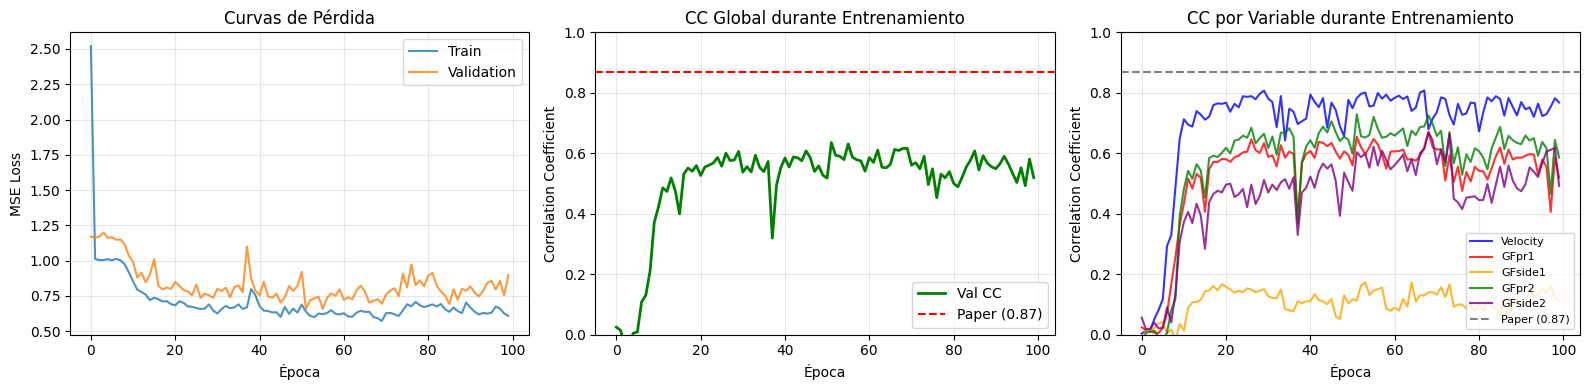


 Figura guardada: curvas_entrenamiento_exp08.png


In [14]:
# ============================================================================
# CELDA 15: VISUALIZAR CURVAS DE ENTRENAMIENTO
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Panel 1: Loss ---
axes[0].plot(loss_hist['train'], label='Train', alpha=0.8)
axes[0].plot(loss_hist['val'], label='Validation', alpha=0.8)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Curvas de Pérdida')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Panel 2: CC Global ---
axes[1].plot(cc_hist['val'], label='Val CC', color='green', linewidth=2)
axes[1].axhline(0.87, color='red', linestyle='--', label='Paper (0.87)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Correlation Coefficient')
axes[1].set_title('CC Global durante Entrenamiento')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])

# --- Panel 3: CC por Variable ---
cc_per_var = np.array(cc_hist['val_per_var'])  # (n_epochs, 5)
colors = ['blue', 'red', 'orange', 'green', 'purple']
for i, (name, color) in enumerate(zip(VAR_NAMES, colors)):
    axes[2].plot(cc_per_var[:, i], label=name, color=color, alpha=0.8)
axes[2].axhline(0.87, color='black', linestyle='--', label='Paper (0.87)', alpha=0.5)
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Correlation Coefficient')
axes[2].set_title('CC por Variable durante Entrenamiento')
axes[2].legend(loc='lower right', fontsize=8)
axes[2].grid(alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('curvas_entrenamiento_exp08.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Figura guardada: curvas_entrenamiento_exp08.png")

In [15]:
# ============================================================================
# CELDA 16: EVALUACIÓN EN TEST CONTINUO (como el paper) + CC y R2
# ============================================================================
modelo.load_state_dict(torch.load('best_model_exp08_definitivo.pth'))
modelo.eval()

# Forward sobre el tramo de test CONTINUO (sin segmentar)
X_cont = MUA_matrix[:, va_end:t1].T
Y_cont = targets_matrix[:, va_end:t1].T
with torch.no_grad():
    out_cont = modelo(torch.FloatTensor(X_cont).unsqueeze(0).to(device)).cpu().numpy()[0]
pred_cont = out_cont * Y_std + Y_mean   # des-normalizar a unidades fisicas

def _cc(a, b):
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return np.nan
    return pearsonr(a, b)[0]
def _r2(p, t):
    ss_res = np.sum((t - p) ** 2); ss_tot = np.sum((t - t.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan

print(f"\n{'='*60}")
print("RESULTADOS EN TEST CONTINUO (metodo del paper)")
print(f"{'='*60}")
cc_test, r2_test = [], []
for i, name in enumerate(VAR_NAMES):
    c = _cc(pred_cont[:, i], Y_cont[:, i])
    r = _r2(pred_cont[:, i], Y_cont[:, i])
    cc_test.append(c); r2_test.append(r)
    print(f"  {name:10}: CC = {c:.4f}   R2 = {r:.4f}")

VCC = cc_test[0]; FCC = np.mean(cc_test[1:])
VR2 = r2_test[0]; FR2 = np.mean(r2_test[1:])
print(f"\n  VCC = {VCC:.4f}   FCC = {FCC:.4f}   (paper: 0.87 / 0.87)")
print(f"  VR2 = {VR2:.4f}   FR2 = {FR2:.4f}   (paper: 0.71 / 0.76)")


RESULTADOS EN TEST CONTINUO (metodo del paper)
  Velocity  : CC = 0.7995   R2 = 0.6304
  GFpr1     : CC = 0.5830   R2 = 0.3301
  GFside1   : CC = 0.1882   R2 = 0.0206
  GFpr2     : CC = 0.6802   R2 = 0.4040
  GFside2   : CC = 0.6265   R2 = 0.3821

  VCC = 0.7995   FCC = 0.5195   (paper: 0.87 / 0.87)
  VR2 = 0.6304   FR2 = 0.2842   (paper: 0.71 / 0.76)


Trials de test dentro del tramo continuo: 12


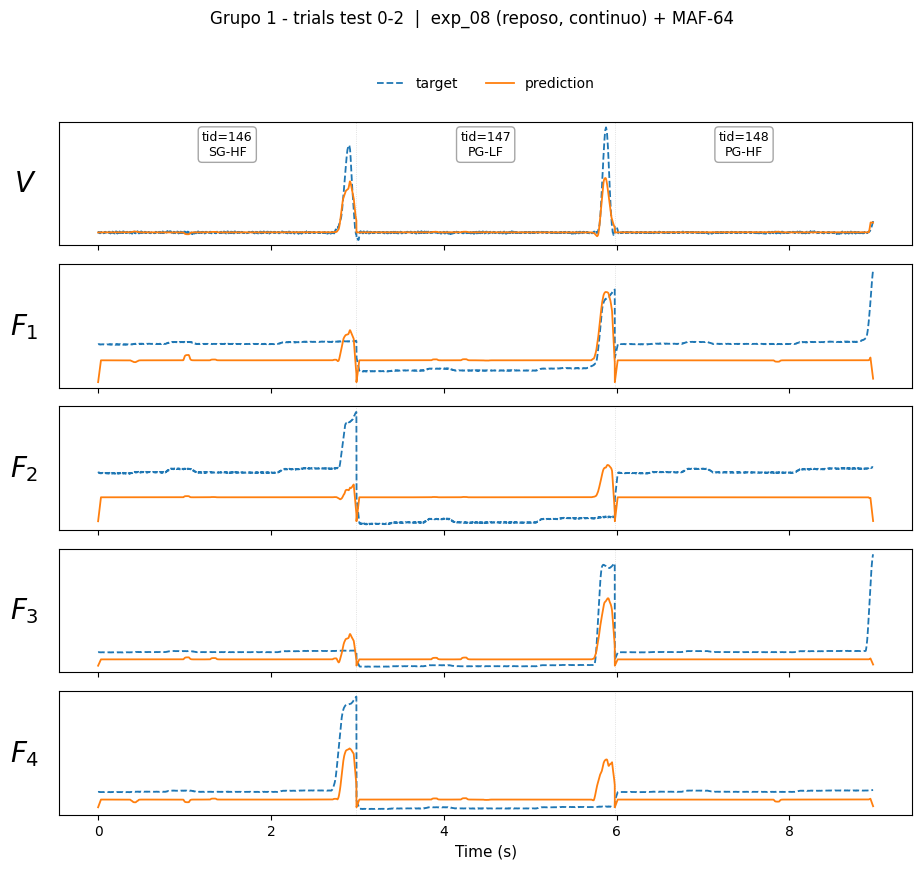

Guardado: fig_exp08_grupo1_trials_0-2.png


In [16]:
# ============================================================================
# CELDA 17: PREDICCIONES vs TARGETS por trial (estilo Figura 5 del paper)
# ============================================================================
# Cortamos el test CONTINUO en sus trials para mostrar la prediccion por trial.
# MAF-64 a la prediccion (el target ya viene suavizado con MAF-64).

def maf1d(a, n=64):
    return np.convolve(a, np.ones(n) / n, mode='same')

test_rows = df_correct[(df_correct['ts_on'] * 1000 >= va_end) &
                       (df_correct['ts_on'] * 1000 + L <= t1)].reset_index(drop=True)
pred_trials, targ_trials, meta_rows = [], [], []
for _, r in test_rows.iterrows():
    ls = int(r['ts_on'] * 1000) - va_end; le = ls + L
    if le > pred_cont.shape[0]:
        continue
    pred_trials.append(np.column_stack([maf1d(pred_cont[ls:le, i]) for i in range(5)]))
    targ_trials.append(Y_cont[ls:le])
    meta_rows.append(r)
pred_trials = np.array(pred_trials)
targ_trials = np.array(targ_trials)
meta_test = pd.DataFrame(meta_rows).reset_index(drop=True)
print(f"Trials de test dentro del tramo continuo: {len(pred_trials)}")

SHORT_LABELS = ['V', r'$F_1$', r'$F_2$', r'$F_3$', r'$F_4$']

def plot_3trials(local_idx, titulo, fname):
    pred_c = np.concatenate([pred_trials[k] for k in local_idx], axis=0)
    targ_c = np.concatenate([targ_trials[k] for k in local_idx], axis=0)
    t_ax = np.arange(pred_c.shape[0]) / 1000.0
    fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True)
    fig.subplots_adjust(hspace=0.15)
    starts = []; acc = 0
    for k in local_idx:
        starts.append(acc); acc += L
    ends = starts[1:] + [acc]
    for i, (ax, lbl) in enumerate(zip(axes, SHORT_LABELS)):
        ax.plot(t_ax, targ_c[:, i], 'tab:blue', ls='--', lw=1.3, label='target' if i == 0 else None)
        ax.plot(t_ax, pred_c[:, i], 'tab:orange', ls='-', lw=1.3, label='prediction' if i == 0 else None)
        for ts in starts[1:]:
            ax.axvline(ts / 1000.0, color='gray', alpha=0.3, lw=0.6, ls=':')
        ax.set_ylabel(lbl, fontsize=20, fontstyle='italic', rotation=0, labelpad=25, va='center')
        ax.set_yticks([]); ax.grid(False)
    for ts, te, k in zip(starts, ends, local_idx):
        m = meta_test.iloc[k]
        label = f"tid={m['trial_id']}\n{m['grip_type']}-{m['force_type']}"
        axes[0].text(((ts + te) / 2.0) / 1000.0, axes[0].get_ylim()[1] * 0.92, label,
                     ha='center', va='top', fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.7))
    axes[-1].set_xlabel('Time (s)', fontsize=11)
    axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    fig.suptitle(titulo, y=1.005)
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")

plot_3trials([0, 1, 2], "Grupo 1 - trials test 0-2  |  exp_08 (reposo, continuo) + MAF-64",
             "fig_exp08_grupo1_trials_0-2.png")

Un trial por tipo: {'SG-HF': 0, 'SG-LF': 8, 'PG-HF': 2, 'PG-LF': 1}


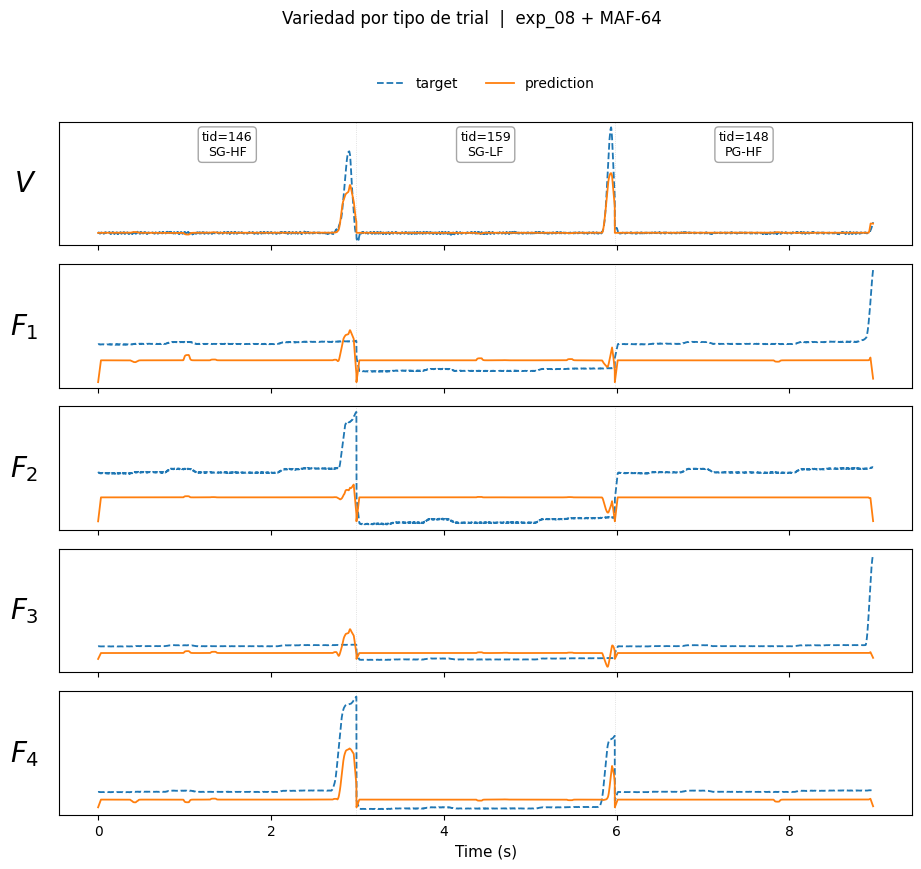

Guardado: fig_exp08_un_trial_por_tipo.png


In [17]:
# ============================================================================
# CELDA 18: UN TRIAL POR TIPO (variedad SG-HF, SG-LF, PG-HF)
# ============================================================================
tipos = {'SG-HF': None, 'SG-LF': None, 'PG-HF': None, 'PG-LF': None}
for k in range(len(meta_test)):
    key = f"{meta_test.iloc[k]['grip_type']}-{meta_test.iloc[k]['force_type']}"
    if key in tipos and tipos[key] is None:
        tipos[key] = k
print(f"Un trial por tipo: {tipos}")
disponibles = [v for v in tipos.values() if v is not None]
if len(disponibles) >= 3:
    plot_3trials(disponibles[:3], "Variedad por tipo de trial  |  exp_08 + MAF-64",
                 "fig_exp08_un_trial_por_tipo.png")